In [1]:
import ModelViz
from sklearn.cluster import KMeans
from sklearn import metrics
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.stats
from matplotlib.gridspec import GridSpec
from matplotlib.transforms import ScaledTranslation


In [2]:
train1 = ModelViz.ModelViz()
# weird formatting of my data....
train1.x_strip = slice(15,-15)
train1.y_strip = slice(15,-15)

classification = 'ecosys'
depth = 'surface'

if classification == 'physics':
    train1.cluster_vars = ['votemper','vosaline','mldr10_1','PAR']
    plot_vars={'votemper':'Temperature','vosaline':'Salinity','mldr10_1':'Mixed layer\ndepth','PAR':'Surface\nirradiance'}
if classification == 'biogeo': 
    train1.cluster_vars = ['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s']
    plot_vars={'N1_p':'Phosphate','N3_n':'Nitrate','O2_o':'Oxygen','O3_c':'DIC','O3_TA':'Alk.', 'N4_n':'Ammon.', 'N5_s':'Silicate'}
if classification == 'ecosys':
    train1.cluster_vars = ['Phytoplankton','Zooplankton','DOC','POC','B1_c']
    plot_vars={'Phytoplankton':'Phytoplankton','Zooplankton':'Zooplankton','DOC':'DOC','POC':'POC','B1_c':'B1_c'}

filename = '/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_'+classification+'.nc'

#train1.cluster_vars = ['N1_p','N3_n']    
    
train1.load_mfdata(filename)
train1.load_grid('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc')

sum_vars={'Phytoplankton': ['P1_c', 'P2_c', 'P3_c', 'P4_c'],
            'Zooplankton': ['Z4_c', 'Z5_c', 'Z6_c'],
            'DOM': ['R1_c', 'R2_c', 'R3_c'],
            'POM': ['R4_c', 'R6_c', 'R8_c']}

train1.norm = 'stdev'

train1.preprocess(do_slice=False)     
#train1.make_tsds()


In [3]:
def cluster_var_names(classification):
    train = ModelViz.ModelViz()

    # weird formatting of my data....
    train.x_strip = slice(15,-15)
    train.y_strip = slice(15,-15)
    train.n_init = 100 #0
    train.seed = 800
    train.norm = 'stdev'

    depth = 'surface'

    if classification == 'physics':
        train.cluster_vars = ['votemper','vosaline','mldr10_1','PAR']
        train.plot_vars=['Temperature','Salinity','Mixed layer\ndepth','PAR']
    if classification == 'biogeo':
        train.cluster_vars = ['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s'] #['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s']
        train.plot_vars=['Phosphate','Nitrate','Oxygen','DIC','Alk.','Ammon.','Silicate']
    if classification == 'ecosys':
        train.cluster_vars = ['Phytoplankton','Zooplankton','DOC','POC','B1_c']
        train.plot_vars=['Phytoplank.','Zooplank.','DOC','POC','Bacteria']
    
    filename = '/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_'+classification+'.nc'

    train.load_mfdata(filename)

    train.load_grid('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc')

    train.preprocess(do_slice=False)     
    return train

sum_vars={'Phytoplankton': ['P1_c', 'P2_c', 'P3_c', 'P4_c'],
            'Zooplankton': ['Z4_c', 'Z5_c', 'Z6_c'],
            'DOM': ['R1_c', 'R2_c', 'R3_c'],
            'POM': ['R4_c', 'R6_c', 'R8_c']}

In [3]:
# calculate r2 values between different variables
train1 = cluster_var_names('ecosys')

results = np.empty((len(train1.cluster_vars),len(train1.cluster_vars)))
for i in range(len(train1.cluster_vars)):
    print(train1.cluster_vars[i])
    vec = []
    for j in range(len(train1.cluster_vars)):
        slope, intercept, val, p_value, std_err = scipy.stats.linregress(train1.ds[train1.cluster_vars[i]].squeeze().stack(Npts=('x', 'y')).where(train1.mask.stack(Npts=('x','y')) == 1, drop=True),\
                                                                         train1.ds[train1.cluster_vars[j]].squeeze().stack(Npts=('x', 'y')).where(train1.mask.stack(Npts=('x','y')) == 1, drop=True))
        results[i,j]=round(val**2,2)
    print('R2 value')
    print(results[i,:])


Phytoplankton
R2 value
[1.   0.56 0.03 0.04 0.3 ]
Zooplankton
R2 value
[0.56 1.   0.34 0.36 0.62]
DOC
R2 value
[0.03 0.34 1.   0.08 0.71]
POC
R2 value
[0.04 0.36 0.08 1.   0.23]
B1_c
R2 value
[0.3  0.62 0.71 0.23 1.  ]


In [4]:
def plot_corr(ax,train,title,label):
    # calculate r2 values between different variables

    results = np.empty((len(train.cluster_vars),len(train.cluster_vars)))
    for i in range(len(train.cluster_vars)):
        vec = []
        for j in range(len(train.cluster_vars)):
            slope, intercept, val, p_value, std_err = scipy.stats.linregress(train.ds[train.cluster_vars[i]].squeeze().stack(Npts=('x', 'y')).where(train.mask.stack(Npts=('x','y')) == 1, drop=True),\
                                                                             train.ds[train.cluster_vars[j]].squeeze().stack(Npts=('x', 'y')).where(train.mask.stack(Npts=('x','y')) == 1, drop=True))
            results[i,j]=round(val**2,2)


    #tick_names = ['Temperature','Salinity','Mixed layer\ndepth','Photosynthetically\nactive radiation']
    #tick_names = ['Phosphate','Nitrate','Oxygen','DIC','Alkalinity','Ammonium','Silicate']
    #tick_names = ['Phytoplankton','Zooplankton','DOC','POC','Bacteria']

    # plotting correlation matrix
    cb = plt.imshow(results, cmap='Blues',vmin=0)

    # Adding labels to the matrix
    plt.xticks(range(len(train.cluster_vars)), train.plot_vars, rotation=45, ha='right')
    plt.yticks(range(len(train.cluster_vars)), train.plot_vars)
    
    plt.title(title)
    
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=12, va='bottom')
    
    return cb

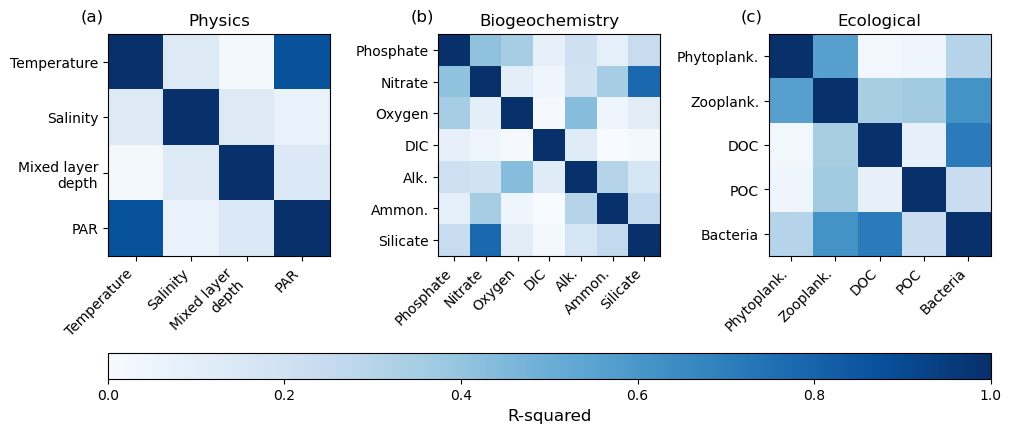

In [5]:
fig = plt.figure(layout="constrained",figsize=[10,4.5])

gs = GridSpec(2, 3, figure=fig,height_ratios=[1,0.08])
ax1 = fig.add_subplot(gs[0,0])
cb = plot_corr(ax1,cluster_var_names('physics'),'Physics','(a)')
ax2 = fig.add_subplot(gs[0,1])
cb = plot_corr(ax2,cluster_var_names('biogeo'),'Biogeochemistry','(b)')
ax3 = fig.add_subplot(gs[0,2])
cb = plot_corr(ax3,cluster_var_names('ecosys'),'Ecological','(c)')
ax4 = fig.add_subplot(gs[1,0:3])
cbar = plt.colorbar(cb,cax=ax4,orientation='horizontal')
cbar.set_label( label='R-squared',size=12)
plt.savefig('all_correlations.png')

In [2]:
#classification = 'biogeo'
rand_scores = []
rand_scores2 = []
for classification in ['ecosys','biogeo','physics']:
    # correlate with results from removing one variable
    filename = 'change_var_results/remove_one_var_'+classification+'.txt'
    rand_scores_full = np.loadtxt(filename,delimiter=',')
    rand_scores.extend(rand_scores_full[:,-2].tolist())

    # correlate with results from removing one variable
    filename = 'change_var_results/one_var_only_'+classification+'.txt'
    rand_scores_full = np.loadtxt(filename,delimiter=',')
    rand_scores2.extend(rand_scores_full[:,-2].tolist())
    
    
slope, intercept, val, p_value, std_err = scipy.stats.linregress(rand_scores2,rand_scores)
print(round(val**2,2))
print(round(p_value,2))

0.01
0.71


In [3]:
results_full = []
for classification in ['ecosys','biogeo','physics']:

    train1 = ModelViz.ModelViz()
    # weird formatting of my data....
    train1.x_strip = slice(15,-15)
    train1.y_strip = slice(15,-15)

    #classification = 'ecosys'
    depth = 'surface'

    if classification == 'physics':
        train1.cluster_vars = ['votemper','vosaline','mldr10_1','PAR']
        plot_vars={'votemper':'Temperature','vosaline':'Salinity','mldr10_1':'Mixed layer\ndepth','PAR':'Surface\nirradiance'}
    if classification == 'biogeo': 
        train1.cluster_vars = ['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s']
        plot_vars={'N1_p':'Phosphate','N3_n':'Nitrate','O2_o':'Oxygen','O3_c':'DIC','O3_TA':'Alk.', 'N4_n':'Ammon.', 'N5_s':'Silicate'}
    if classification == 'ecosys':
        train1.cluster_vars = ['Phytoplankton','Zooplankton','DOC','POC','B1_c']
        plot_vars={'Phytoplankton':'Phytoplankton','Zooplankton':'Zooplankton','DOC':'DOC','POC':'POC','B1_c':'B1_c'}

    filename = '/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_'+classification+'.nc'

    #train1.cluster_vars = ['N1_p','N3_n']    

    train1.load_mfdata(filename)
    train1.load_grid('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc')

    sum_vars={'Phytoplankton': ['P1_c', 'P2_c', 'P3_c', 'P4_c'],
                'Zooplankton': ['Z4_c', 'Z5_c', 'Z6_c'],
                'DOM': ['R1_c', 'R2_c', 'R3_c'],
                'POM': ['R4_c', 'R6_c', 'R8_c']}

    train1.norm = 'stdev'

    train1.preprocess(do_slice=False)     
    #train1.make_tsds()
    # calculate r2 values between different variables

    results = np.empty((len(train1.cluster_vars),len(train1.cluster_vars)))
    for i in range(len(train1.cluster_vars)):
        #print(train1.cluster_vars[i])
        for j in range(len(train1.cluster_vars)):
            slope, intercept, val, p_value, std_err = scipy.stats.linregress(train1.ds[train1.cluster_vars[i]].squeeze().stack(Npts=('x', 'y')).where(train1.mask.stack(Npts=('x','y')) == 1, drop=True),\
                                                                             train1.ds[train1.cluster_vars[j]].squeeze().stack(Npts=('x', 'y')).where(train1.mask.stack(Npts=('x','y')) == 1, drop=True))
            results[i,j]=round(val**2,2)
    mean_r2 = (results.sum(axis=0)-1)/(len(train1.cluster_vars)-1)
    results_full.extend(mean_r2.tolist())


In [90]:
results_full

[0.23250000000000004,
 0.4700000000000001,
 0.29000000000000004,
 0.1775,
 0.46499999999999997,
 0.22999999999999998,
 0.3116666666666667,
 0.17333333333333334,
 0.045000000000000005,
 0.23500000000000001,
 0.17333333333333334,
 0.2616666666666667,
 0.34,
 0.10999999999999995,
 0.09666666666666668,
 0.36000000000000004]

In [6]:
slope, intercept, val, p_value, std_err = scipy.stats.linregress(results_full,rand_scores)
print(round(val,2))
print(round(p_value,2))

0.58
0.02
